# Сквозной разбор текста с ruTS

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SergeyShk/ruTS/blob/master/examples/01_text_walkthrough.ipynb)

Один рассказ - и все инструменты библиотеки [ruTS](https://github.com/SergeyShk/ruTS) по порядку: извлечение предложений и слов, базовые статистики, удобочитаемость, лексическое разнообразие, морфология, SEO-метрики стиля, фоностатистика, синтаксис и связность по разбору spaCy, лексическая сложность по частотному словарю, подсветка и графики, а в конце - компоненты spaCy и обработка целого корпуса в таблицу.

Каждый раздел ссылается на страницу [документации](https://sergeyshk.github.io/ruTS/), где описаны все статистики и параметры.

## Установка

В Colab ячейка ставит библиотеку и модель spaCy `ru_core_news_sm`; в окружении, где они уже есть, ничего не делает. Стоп-слова NLTK нужны только для примера с `WordsExtractor`.

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("ruts") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ruts"], check=True)
if importlib.util.find_spec("ru_core_news_sm") is None:
    subprocess.run(
        [sys.executable, "-m", "spacy", "download", "ru_core_news_sm", "-q"], check=True
    )

In [2]:
import nltk

try:
    nltk.data.find("corpora/stopwords")
except LookupError:
    nltk.download("stopwords", quiet=True)

In [3]:
import ruts

ruts.__version__

'0.14.0.dev1'

## Текст

Рассказ А. П. Чехова «Смерть чиновника» (1883) - 677 слов, 81 предложение; текст из собрания [RusLit](https://github.com/d0rj/RusLit), которое доступно в библиотеке как набор данных `RussianLiterature`. Любой другой текст можно подставить в `TEXT`.

In [4]:
TEXT = """\
В один прекрасный вечер не менее прекрасный экзекутор, Иван Дмитрич Червяков, сидел во втором ряду кресел и глядел в бинокль на «Корневильские колокола». Он глядел и чувствовал себя на верху блаженства. Но вдруг... В рассказах часто встречается это «но вдруг». Авторы правы: жизнь так полна внезапностей! Но вдруг лицо его поморщилось, глаза подкатились, дыхание остановилось... он отвел от глаз бинокль, нагнулся и.. апчхи!!! Чихнул, как видите. Чихать никому и нигде не возбраняется. Чихают и мужики, и полицеймейстеры, и иногда даже и тайные советники. Все чихают. Червяков нисколько не сконфузился, утерся платочком и, как вежливый человек, поглядел вокруг себя: не обеспокоил ли он кого-нибудь своим чиханьем? Но тут уж пришлось сконфузиться. Он увидел, что старичок, сидевший впереди него, в первом ряду кресел, старательно вытирал свою лысину и шею перчаткой и бормотал что-то. В старичке Червяков узнал статского генерала Бризжалова, служащего по ведомству путей сообщения.
«Я его обрызгал! — подумал Червяков. — Не мой начальник, чужой, но все-таки неловко. Извиниться надо».
Червяков кашлянул, подался туловищем вперед и зашептал генералу на ухо:
— Извините, ваше — ство, я вас обрызгал... я нечаянно...
— Ничего, ничего...
— Ради бога, извините. Я ведь... я не желал!
— Ах, сидите, пожалуйста! Дайте слушать!
Червяков сконфузился, глупо улыбнулся и начал глядеть на сцену. Глядел он, но уж блаженства больше не чувствовал. Его начало помучивать беспокойство. В антракте он подошел к Бризжалову, походил возле него и, поборовши робость, пробормотал:
— Я вас обрызгал, ваше — ство... Простите... Я ведь... не то чтобы...
— Ах, полноте... Я уж забыл, а вы всё о том же! — сказал генерал и нетерпеливо шевельнул нижней губой.
«Забыл, а у самого ехидство в глазах, — подумал Червяков, подозрительно поглядывая на генерала. — И говорить не хочет. Надо бы ему объяснить, что я вовсе не желал... что это закон природы, а то подумает, что я плюнуть хотел. Теперь не подумает, так после подумает!..»
Придя домой, Червяков рассказал жене о своем невежестве. Жена, как показалось ему, слишком легкомысленно отнеслась к происшедшему; она только испугалась, а потом, когда узнала, что Бризжалов «чужой», успокоилась.
— А все-таки ты сходи, извинись, — сказала она. — Подумает, что ты себя в публике держать не умеешь!
— То-то вот и есть! Я извинялся, да он как-то странно... Ни одного слова путного не сказал. Да и некогда было разговаривать.
На другой день Червяков надел новый вицмундир, постригся и пошел к Бризжалову объяснить... Войдя в приемную генерала, он увидел там много просителей, а между просителями и самого генерала, который уже начал прием прошений. Опросив несколько просителей, генерал поднял глаза и на Червякова.
— Вчера в «Аркадии», ежели припомните, ваше — ство, — начал докладывать экзекутор, — я чихнул-с и... нечаянно обрызгал... Изв...
— Какие пустяки... Бог знает что! Вам что угодно? — обратился генерал к следующему просителю.
«Говорить не хочет! — подумал Червяков, бледнея. — Сердится, значит... Нет, этого нельзя так оставить... Я ему объясню...»
Когда генерал кончил беседу с последним просителем и направился во внутренние апартаменты, Червяков шагнул за ним и забормотал:
— Ваше — ство! Ежели я осмеливаюсь беспокоить ваше — ство, то именно из чувства, могу сказать, раскаяния!.. Не нарочно, сами изволите знать-с!
Генерал состроил плаксивое лицо и махнул рукой.
— Да вы просто смеетесь, милостисдарь! — сказал он, скрываясь за дверью.
«Какие же тут насмешки? — подумал Червяков. — Вовсе тут нет никаких насмешек! Генерал, а не может понять! Когда так, не стану же я больше извиняться перед этим фанфароном! Чёрт с ним! Напишу ему письмо, а ходить не стану! Ей-богу, не стану!»
Так думал Червяков, идя домой. Письма генералу он не написал. Думал, думал, и никак не выдумал этого письма. Пришлось на другой день идти самому объяснять.
— Я вчера приходил беспокоить ваше — ство, — забормотал он, когда генерал поднял на него вопрошающие глаза, — не для того, чтобы смеяться, как вы изволили сказать. Я извинялся за то, что, чихая, брызнул-с..., а смеяться я и не думал. Смею ли я смеяться? Ежели мы будем смеяться, так никакого тогда, значит, и уважения к персонам... не будет...
— Пошел вон!! — гаркнул вдруг посиневший и затрясшийся генерал.
— Что-с? — спросил шёпотом Червяков, млея от ужаса.
— Пошел вон!! — повторил генерал, затопав ногами.
В животе у Червякова что-то оторвалось. Ничего не видя, ничего не слыша, он попятился к двери, вышел на улицу и поплелся... Придя машинально домой, не снимая вицмундира, он лег на диван и... помер.
"""

print(TEXT[:300], "...")

В один прекрасный вечер не менее прекрасный экзекутор, Иван Дмитрич Червяков, сидел во втором ряду кресел и глядел в бинокль на «Корневильские колокола». Он глядел и чувствовал себя на верху блаженства. Но вдруг... В рассказах часто встречается это «но вдруг». Авторы правы: жизнь так полна внезапнос ...


## Извлечение предложений и слов

Экстракторы - настраиваемые инструменты, которые классы статистик используют внутри и которые можно передавать им явно. `SentsExtractor` делит текст на предложения через [razdel](https://github.com/natasha/razdel), `WordsExtractor` извлекает слова с опциональной лемматизацией, фильтрацией стоп-слов и чисел и N-граммами, `CharNgramsExtractor` - символьные N-граммы для стилометрии. Документация: [предложения](https://sergeyshk.github.io/ruTS/extractors/sentences/), [слова](https://sergeyshk.github.io/ruTS/extractors/words/), [символьные N-граммы](https://sergeyshk.github.io/ruTS/extractors/char_ngrams/).

In [5]:
from ruts import CharNgramsExtractor, SentsExtractor, WordsExtractor

se = SentsExtractor()
sents = se.extract(TEXT)
print(len(sents), "предложений, первые три:")
for sent in sents[:3]:
    print("  -", sent)

81 предложений, первые три:
  - В один прекрасный вечер не менее прекрасный экзекутор, Иван Дмитрич Червяков, сидел во втором ряду кресел и глядел в бинокль на «Корневильские колокола».
  - Он глядел и чувствовал себя на верху блаженства.
  - Но вдруг...


In [6]:
from nltk.corpus import stopwords

we = WordsExtractor()
words = we.extract(TEXT)
print(len(words), "слов:", words[:10])

# Леммы в нижнем регистре без стоп-слов и чисел
we_lemmas = WordsExtractor(
    use_lexemes=True, lowercase=True, stopwords=stopwords.words("russian"), filter_nums=True
)
lemmas = we_lemmas.extract(TEXT)
print(len(lemmas), "лемм, самые частые:", we_lemmas.get_most_common(8))

# Биграммы лемм
we_bigrams = WordsExtractor(use_lexemes=True, lowercase=True, ngram_range=(2, 2))
we_bigrams.extract(TEXT)
print("биграммы:", we_bigrams.get_most_common(5))

677 слов: ('В', 'один', 'прекрасный', 'вечер', 'не', 'менее', 'прекрасный', 'экзекутор', 'Иван', 'Дмитрич')
412 лемм, самые частые: [('генерал', 15), ('червяк', 14), ('подумать', 8), ('ваш', 6), ('ство', 6), ('сказать', 6), ('это', 5), ('глаз', 5)]
биграммы: [('ваш_ство', 6), ('подумать_червяк', 4), ('но_вдруг', 3), ('не_стать', 3), ('ряд_кресло', 2)]


In [7]:
ce = CharNgramsExtractor(n=3, lowercase=True)
ce.extract(TEXT)
ce.get_most_common(5)

[(' — ', 42), (' не', 40), (' по', 39), ('не ', 28), (' и ', 26)]

## Базовые статистики

`BasicStats` считает предложения, слова, буквы, слоги и знаки препинания, а также распределения слов по числу букв и слогов. У каждого класса статистик есть `get_stats()` - словарь значений - и `print_stats()` - таблица с описаниями. Документация: [базовые статистики](https://sergeyshk.github.io/ruTS/stats/basic_stats/).

In [8]:
from ruts import BasicStats

bs = BasicStats(TEXT)
bs.print_stats()

     Статистика     | Значение 
------------------------------
Предложения         |    81    
Слова               |   677    
Уникальные слова    |   380    
Длинные слова       |   297    
Сложные слова       |    95    
Простые слова       |   563    
Односложные слова   |   215    
Многосложные слова  |   443    
Символы             |   4545   
Буквы               |   3522   
Пробелы             |   690    
Слоги               |   1469   
Знаки препинания    |   279    


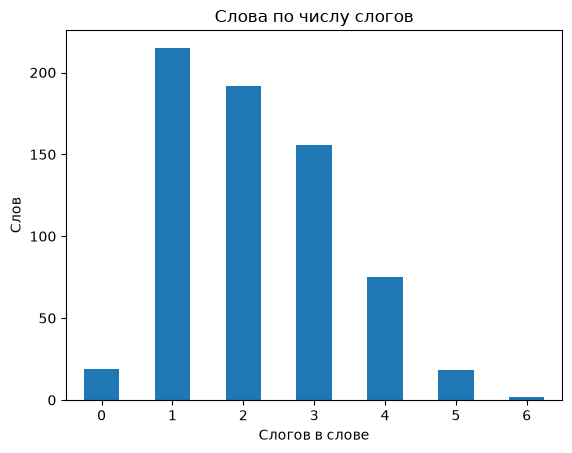

In [9]:
import pandas as pd

ax = (
    pd.Series(bs.c_syllables)
    .sort_index()
    .plot.bar(rot=0, title="Слова по числу слогов", xlabel="Слогов в слове", ylabel="Слов")
)

Знаки препинания считаются по типам (`c_punctuations`), а `punctuation_profile` нормирует их на 1000 слов - так удобно сравнивать тексты разной длины. У Чехова заметны многоточия и восклицания.

In [10]:
from ruts.basic_stats import punctuation_profile

{name: value for name, value in punctuation_profile(TEXT).items() if value}

{'comma': 141.80206794682422,
 'period': 67.94682422451994,
 'question': 7.385524372230428,
 'exclamation': 41.3589364844904,
 'ellipsis': 41.3589364844904,
 'colon': 7.385524372230428,
 'semicolon': 1.4771048744460857,
 'dash': 62.0384047267356,
 'hyphen': 17.725258493353028,
 'angle_quotes': 23.633677991137372,
 'yo_share': 0.00974025974025974}

## Удобочитаемость

`ReadabilityStats` вычисляет одиннадцать формул с коэффициентами для русского языка, сводный класс по медиане формул и время чтения; `describe_grade()` переводит класс в возраст читателя. Коэффициенты задаются пресетом: `plainrussian` (по умолчанию, тексты с метками класса), `fiction` (Оборнева, художественные тексты), `academic` (учебные). Документация: [метрики удобочитаемости](https://sergeyshk.github.io/ruTS/stats/readability_stats/).

In [11]:
from ruts import ReadabilityStats

rs = ReadabilityStats(TEXT)
rs.print_stats()
print()
print("Сводный класс:", rs.describe_grade())

                   Метрика                   | Значение 
-------------------------------------------------------
Тест Флеша-Кинкайда                          |   2.97   
Индекс удобочитаемости Флеша                 |  65.56   
Индекс Колман-Лиау                           |   4.10   
Индекс SMOG                                  |   4.44   
Автоматический индекс удобочитаемости        |   3.87   
Индекс удобочитаемости LIX                   |  41.89   
Индекс удобочитаемости RIX                   |   2.80   
Формула Соловьёва, Иванова, Солнышкиной      |  -0.07   
Формула Мацковского                          |   6.96   
Индекс Дейла-Чейла                           |   3.91   
Индекс Ганнинга                              |   4.52   
Сводный класс                                |   4.00   
Время чтения (мин.)                          |   3.76   

Сводный класс: 4-6-й класс (9-11 лет)


In [12]:
pd.DataFrame(
    {
        preset: ReadabilityStats(TEXT, preset=preset).get_stats()
        for preset in ("plainrussian", "fiction", "academic")
    }
).round(2)

,plainrussian,fiction,academic
flesch_kincaid_grade,2.97,6.82,3.54
flesch_reading_easy,65.56,65.56,52.79
coleman_liau_index,4.10,4.10,4.10
smog_index,4.44,4.44,4.44
automated_readability_index,3.87,3.87,3.87
lix,41.89,41.89,41.89
rix,2.80,2.80,2.80
sis_grade,-0.07,-0.07,-0.07
matskovsky_index,6.96,6.96,6.96
dale_chall_index,3.91,3.91,3.91


## Лексическое разнообразие

`DiversityStats` - три десятка мер от TTR до MTLD, HD-D и характеристик Юла. Простые меры зависят от длины текста, поэтому для сравнения текстов разной длины есть оконный расчет `windowed`: метрика по последовательным окнам, среднее и доверительный интервал. Документация: [метрики лексического разнообразия](https://sergeyshk.github.io/ruTS/stats/diversity_stats/).

In [13]:
from ruts import DiversityStats

ds = DiversityStats(TEXT)
selected = ("ttr", "mattr", "mtld", "hdd", "yule_k", "entropy", "hapax_ratio", "heaps_beta")
{name: round(ds.get_stats()[name], 3) for name in selected}

{'ttr': 0.561,
 'mattr': 0.865,
 'mtld': 175.428,
 'hdd': 0.892,
 'yule_k': 71.172,
 'entropy': 7.929,
 'hapax_ratio': 0.729,
 'heaps_beta': 0.88}

In [14]:
ds.windowed("mtld", window_len=100)

WindowStats(mean=144.80898730898733, std=32.4228617816475, lower=110.78328060790503, upper=178.83469401006963, n_windows=6)

## Морфология

`MorphStats` размечает слова признаками [Universal Dependencies](https://universaldependencies.org/u/feat/): для строки - первым разбором pymorphy3, для `Doc` spaCy - разметкой модели с учетом контекста. `print_stats` принимает названия признаков, `explain_text` показывает разбор каждого слова. Документация: [морфологические статистики](https://sergeyshk.github.io/ruTS/stats/morph_stats/).

In [15]:
from ruts import MorphStats

ms = MorphStats(TEXT)
ms.print_stats("pos", "tense", "aspect")

---------------Часть речи---------------
Глагол                        |   181    
Имя существительное           |   128    
Местоимение-существительное   |    64    
Наречие                       |    61    
Сочинительный союз            |    61    
Предлог                       |    50    
Частица                       |    48    
Имя прилагательное            |    26    
Подчинительный союз           |    22    
Местоимение-прилагательное    |    22    
Имя собственное               |    6     
Междометие                    |    5     
Числительное                  |    2     
Прочее                        |    1     

-----------------Время------------------
Неизвестно                    |   525    
Прошедшее                     |   105    
Настоящее                     |    31    
Будущее                       |    16    

------------------Вид-------------------
Неизвестно                    |   496    
Совершенный                   |   110    
Несовершенный                 |    

In [16]:
ms_sent = MorphStats(sents[0])
ms_sent.explain_text("pos", "case", "number", "tense", filter_none=True)[:8]

(('В', {'pos': 'ADP'}),
 ('один', {'pos': 'NUM', 'case': 'Nom', 'number': 'Sing'}),
 ('прекрасный', {'pos': 'ADJ', 'case': 'Nom', 'number': 'Sing'}),
 ('вечер', {'pos': 'NOUN', 'case': 'Acc', 'number': 'Sing'}),
 ('не', {'pos': 'PART'}),
 ('менее', {'pos': 'ADV'}),
 ('прекрасный', {'pos': 'ADJ', 'case': 'Nom', 'number': 'Sing'}),
 ('экзекутор', {'pos': 'NOUN', 'case': 'Nom', 'number': 'Sing'}))

## SEO-метрики стиля

`StyleStats` повторяет показатели сервисов Advego и Text.ru (тошнота, водность, заспамленность, естественность по Ципфу) и считает лексические маркеры канцелярита. Показатели сервисов придуманы для проверки веб-текстов на переспам, поэтому на рассказе сами по себе говорят мало; маркеры канцелярита работают на любом тексте - у Чехова они почти нулевые, для контраста ниже тот же класс на официальном абзаце. Документация: [SEO-метрики стиля](https://sergeyshk.github.io/ruTS/stats/style_stats/).

In [17]:
from ruts import StyleStats

ss = StyleStats(TEXT)
ss.print_stats()
print()
print(ss.keyword_density("червяков", "генерал", "извините"))

                     Метрика                      | Значение 
------------------------------------------------------------
Классическая тошнота                              |   5.57   
Академическая тошнота (%)                         |  22.60   
Водность (%)                                      |  41.95   
Заспамленность (%)                                |  43.87   
Естественность по Ципфу (%)                       |   0.00   
Отглагольные существительные (% существительных)  |   4.48   
Производные предлоги (на 100 слов)                |   0.00   
Вводные слова (на 100 слов)                       |   0.30   
Штампы (на 100 слов)                              |   0.00   

{'червяков': 2.06794682422452, 'генерал': 1.329394387001477, 'извините': 0.29542097488921715}


In [18]:
OFFICIAL = (
    "В целях повышения эффективности использования бюджетных средств в кратчайшие сроки "
    "проводится проверка целевого расходования. По итогам проверки, как правило, "
    "осуществляется подготовка предложений по оптимизации в связи с необходимостью "
    "обеспечения исполнения поручений в установленном порядке."
)
pd.DataFrame({"Чехов": ss.get_stats(), "Канцелярит": StyleStats(OFFICIAL).get_stats()}).round(2)

,Чехов,Канцелярит
classic_nausea,5.57,2.00
academic_nausea,22.60,41.18
water,41.95,23.53
spam,43.87,11.76
zipf_naturalness,0.00,91.67
verbal_nouns,4.48,40.00
compound_prepositions,0.00,5.88
parentheticals,0.30,2.94
cliches,0.00,8.82


## Фоностатистика

`PhonStats` работает с буквенной записью: доли гласных и классов согласных, консонантные кластеры и зияния, энтропия CV-шаблонов, индексы аллитерации и ассонанса относительно ожидаемых повторов, слоги по правилу восходящей звучности. Документация: [фоностатистики](https://sergeyshk.github.io/ruTS/stats/phon_stats/).

In [19]:
from ruts import PhonStats
from ruts.phon_stats import syllabify

ps = PhonStats(TEXT)
ps.print_stats()
print()
print(syllabify("экзекутор"), syllabify("Червяков"), syllabify("здравствуйте"))

               Статистика               | Значение 
--------------------------------------------------
Доля гласных                            |   0.43   
Доля сонорных согласных                 |   0.20   
Доля звонких шумных согласных           |   0.15   
Доля глухих шумных согласных            |   0.22   
Отношение согласных к гласным           |   1.35   
Доля кластеров из 3 и более согласных   |   0.02   
Зияний гласных на слово                 |   0.01   
Энтропия CV-шаблонов слов (бит)         |   5.65   
Жёсткость                               |   0.35   
Индекс аллитерации                      |   1.04   
Индекс ассонанса                        |   1.00   
Доля открытых слогов                    |   0.75   
Средняя длина слога (букв)              |   2.38   

['э', 'кзе', 'ку', 'тор'] ['чер', 'вя', 'ков'] ['здра', 'вствуй', 'те']


## Синтаксис и связность по разбору spaCy

Синтаксические статистики и статистики связности требуют разбора зависимостей, поэтому принимают объект `Doc` spaCy. Все остальные классы тоже принимают `Doc` - тогда слова и предложения берутся из разметки модели, а не из razdel. Документация: [синтаксические статистики](https://sergeyshk.github.io/ruTS/stats/syntax_stats/), [статистики связности](https://sergeyshk.github.io/ruTS/stats/cohesion_stats/).

In [20]:
import spacy

nlp = spacy.load("ru_core_news_sm")
doc = nlp(TEXT)
print("предложений по spaCy:", len(list(doc.sents)), "| по razdel:", bs.n_sents)
print("слов по spaCy:", BasicStats(doc).n_words, "| по razdel:", bs.n_words)

предложений по spaCy: 75 | по razdel: 81
слов по spaCy: 677 | по razdel: 677


In [21]:
from ruts import SyntaxStats

xs = SyntaxStats(doc)
xs.print_stats()

                    Статистика                    | Значение 
------------------------------------------------------------
Средняя длина зависимости                         |   2.31   
Стандартное отклонение длины зависимости          |   2.22   
Максимальная длина зависимости                    |   4.84   
Доля смежных связей                               |   0.50   
Глубина дерева зависимостей                       |   2.65   
Листьев на предложение                            |   5.33   
Поддеревьев на предложение                        |   3.85   
Узлов на лист                                     |   1.80   
Валентность финитных глаголов                     |   1.90   
Сочинительных цепочек на предложение              |   0.57   
Средняя длина сочинительной цепочки               |   2.44   
Клауз на предложение                              |   2.20   
Средняя длина клаузы (слов)                       |   4.18   
Придаточных клауз на предложение                  |   0.29   
Доля пред

In [22]:
from ruts import CohesionStats

cs = CohesionStats(doc)
cs.print_stats()

                        Статистика                        | Значение 
--------------------------------------------------------------------
Повтор существительных в соседних предложениях            |   0.12   
Повтор существительных во всех парах предложений          |   0.08   
Повтор аргументов в соседних предложениях                 |   0.26   
Повтор аргументов во всех парах предложений               |   0.18   
Повтор знаменательных слов в соседних предложениях        |   0.28   
Повтор знаменательных слов во всех парах предложений      |   0.12   
Доля общих знаменательных слов в соседних предложениях    |   0.06   
Доля общих знаменательных слов во всех парах предложений  |   0.02   
Доля местоимений                                          |   0.14   
Отношение местоимений к существительным                   |   0.63   
Доля указательных местоимений                             |   0.01   
Доля знаменательных слов, встречавшихся ранее             |   0.36   
Повтор времени в сосе

## Лексическая сложность по частотному словарю

`LexicalStats` опирается на частотный словарь Ляшевской и Шарова (52 138 лемм по НКРЯ): средняя частотность и диапазон лемм, сюрпризал и перплексия, покрытие словарем. Словарь загружается один раз (`FreqDict().download()`, около 500 КБ), доли частотных полос топ-1000...10000 работают и без него. Документация: [статистики лексической сложности](https://sergeyshk.github.io/ruTS/stats/lexical_stats/).

In [23]:
from ruts import LexicalStats
from ruts.datasets import FreqDict

FreqDict().download()
ls = LexicalStats(doc)
ls.print_stats()

                        Статистика                        | Значение 
--------------------------------------------------------------------
Доля слов, найденных в частотном словаре                  |   0.96   
Средняя частотность (ipm)                                 | 5255.96  
Средняя частотность знаменательных слов (ipm)             |  420.38  
Средняя логарифмическая частотность (lg ipm)              |   2.68   
Средняя логарифмическая частотность знаменательных слов   |   1.91   
Средний диапазон (R)                                      |  95.86   
Средняя дисперсия (D)                                     |  94.18   
Средний сюрпризал (бит)                                   |  11.46   
Униграммная перплексия                                    | 2811.38  
Доля слов из топ-1000                                     |   0.65   
Доля слов из топ-2000                                     |   0.73   
Доля слов из топ-5000                                     |   0.77   
Доля слов из топ-1000

## Подсветка и графики

`highlight` размечает текст по слоям в стиле Главреда: длинные предложения, сложные и редкие слова, пассив, обороты, канцелярит, стоп-слова, аллитерации; синтаксические слои доступны для `Doc`. Результат отображается в Jupyter как HTML с легендой и всплывающими пояснениями, `to_html()` отдает разметку. Документация: [подсветка текста](https://sergeyshk.github.io/ruTS/visualizers/highlight/).

In [24]:
from ruts.visualizers import highlight

ht = highlight(
    doc, layers=["long_sents", "converb_clauses", "participle_clauses", "passive", "alliteration"]
)
print(ht.counts)
ht

{'long_sents': 8, 'passive': 4, 'participle_clauses': 4, 'converb_clauses': 10, 'alliteration': 3}


HighlightedText(counts={'long_sents': 8, 'passive': 4, 'participle_clauses': 4, 'converb_clauses': 10, 'alliteration': 3})

Графики matplotlib принимают оси `ax` и возвращают `Axes`. Закон Ципфа строится по счетчику слов с подгонкой Ципфа-Мандельброта, кривая длин предложений показывает ритм текста со скользящим средним и гистограммой длин. Документация: [закон Ципфа](https://sergeyshk.github.io/ruTS/visualizers/zipf/), [длины предложений](https://sergeyshk.github.io/ruTS/visualizers/sentences/).

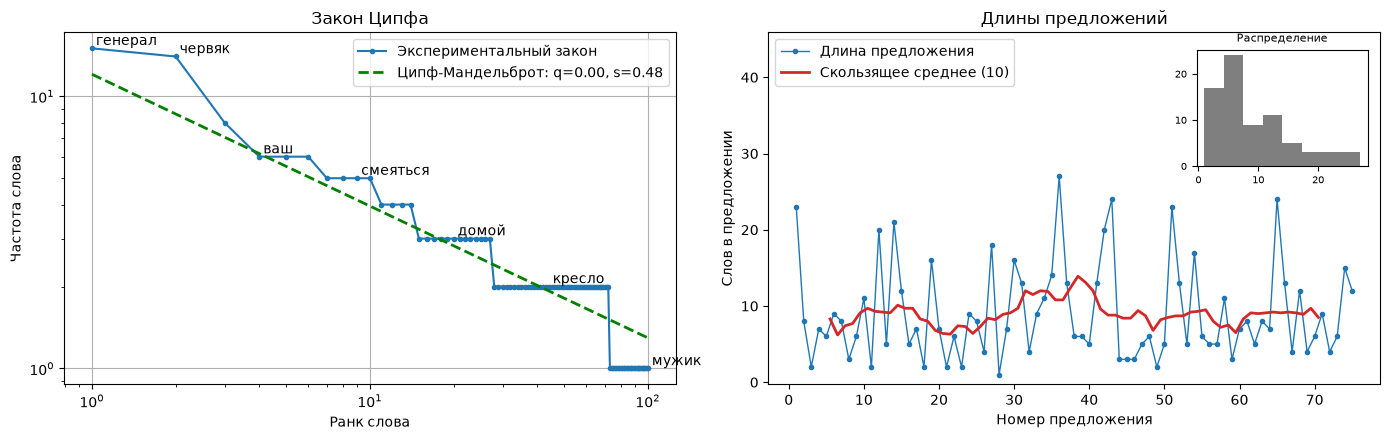

In [25]:
from collections import Counter

import matplotlib.pyplot as plt

from ruts.visualizers import sentence_lengths_plot, zipf

fig, (ax_zipf, ax_sents) = plt.subplots(1, 2, figsize=(14, 4.5))
zipf(Counter(lemmas), num_words=100, num_labels=8, show_fit=True, ax=ax_zipf)
sentence_lengths_plot(doc, window=10, ax=ax_sents)
fig.tight_layout()

## Компоненты spaCy и обработка корпуса

Каждый класс статистик есть и как компонент пайплайна spaCy: `nlp.add_pipe("basic")` кладет объект `BasicStats` в `doc._.basic`. Так один проход `nlp.pipe` по корпусу дает все статистики сразу. Ниже - набор данных `TextsByGrade` (68 текстов с метками класса проекта Plain Russian Language) в таблицу и проверка, какие статистики растут вместе с классом. Документация: [компоненты](https://sergeyshk.github.io/ruTS/components/), [наборы данных](https://sergeyshk.github.io/ruTS/datasets/textsbygrade/).

In [26]:
from ruts.datasets import TextsByGrade

for name in ("basic", "readability", "diversity", "syntax", "cohesion", "lexical"):
    nlp.add_pipe(name, last=True)
print(nlp.pipe_names)

tbg = TextsByGrade()
tbg.download()
records = list(tbg.get_records())
len(records)

['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'ner', 'basic', 'readability', 'diversity', 'syntax', 'cohesion', 'lexical']


68

In [27]:
rows = []
for record, d in zip(records, nlp.pipe(r["text"] for r in records), strict=True):
    rows.append(
        {
            "grade": record["grade"],
            "n_words": d._.basic.n_words,
            "consensus_grade": d._.readability.consensus_grade,
            "mtld": d._.diversity.mtld,
            "tree_depth": d._.syntax.tree_depth,
            "clauses_per_sent": d._.syntax.clauses_per_sent,
            "p_passive": d._.syntax.p_passive,
            "noun_overlap_adjacent": d._.cohesion.noun_overlap_adjacent,
            "surprisal": d._.lexical.surprisal,
        }
    )
df = pd.DataFrame(rows)
df.groupby("grade").mean().round(2)

,n_words,consensus_grade,mtld,tree_depth,clauses_per_sent,p_passive,noun_overlap_adjacent,surprisal
grade,,,,,,,,
1,961.91,3.18,166.37,3.04,2.38,0.04,0.28,12.04
3,336.67,3.83,251.79,3.19,2.15,0.03,0.24,11.67
4,772.00,6.57,354.90,3.57,2.17,0.07,0.23,11.64
5,742.00,7.50,220.68,3.88,2.39,0.05,0.25,11.33
6,1947.75,4.62,247.65,2.91,1.91,0.04,0.18,11.36
7,2149.00,4.75,261.49,3.30,2.46,0.05,0.15,11.45
8,989.67,9.33,323.79,4.88,2.87,0.10,0.35,11.66
9,449.50,7.75,343.65,3.80,2.62,0.08,0.27,11.78
10,451.00,8.67,501.21,4.13,2.18,0.14,0.21,12.15


In [28]:
df.corr(method="spearman")["grade"].drop("grade").round(2).sort_values(ascending=False)

consensus_grade          0.81
tree_depth               0.75
p_passive                0.73
noun_overlap_adjacent    0.32
surprisal                0.11
mtld                    -0.00
n_words                 -0.18
clauses_per_sent        -0.30
Name: grade, dtype: float64

Сводный класс удобочитаемости и глубина дерева зависимостей растут с классом текста, лексическое разнообразие MTLD - нет: оно измеряет другое. Подробный разбор этой зависимости по всем формулам и классам статистик - тема отдельного ноутбука.

## Что дальше

*   [Документация](https://sergeyshk.github.io/ruTS/) - все статистики, параметры и формулы с источниками.
*   [Корпусные меры и стилометрия](https://sergeyshk.github.io/ruTS/corpus/keyness/): ключевые слова, коллокации, дисперсия, KWIC, дельта Барроуза, сравнение корпусов `compare_corpora`.
*   [Демо на Hugging Face Spaces](https://huggingface.co/spaces/SergeyShk/ruTS) - вставьте свой текст и посмотрите подсветку и статистики без установки.